# CycleGAN: Unpaired Image-to-Image Translation

**Paper:** [Unpaired Image-to-Image Translation using Cycle-Consistent Adversarial Networks](https://arxiv.org/abs/1703.10593)

This notebook implements CycleGAN from scratch in PyTorch, training two generator-discriminator pairs with cycle consistency loss to translate images between two domains **without paired data**.


## 1. Setup & Imports


In [1]:
!pip install -q torch torchvision matplotlib numpy Pillow

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.utils import save_image, make_grid
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
import itertools

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Hyperparameters
IMG_SIZE = 128
BATCH_SIZE = 4
LR = 0.0002
EPOCHS = 1
LAMBDA_CYCLE = 10.0
LAMBDA_IDENTITY = 0.5
NUM_RESIDUAL = 4  # Simplified from 9 in original paper


Device: cpu


## 2. Synthetic Dataset (Unpaired Domains)

We create two synthetic image domains — Domain A (circles with warm colors) and Domain B (squares with cool colors). This mimics the unpaired setting where we have images from two domains but no correspondences.


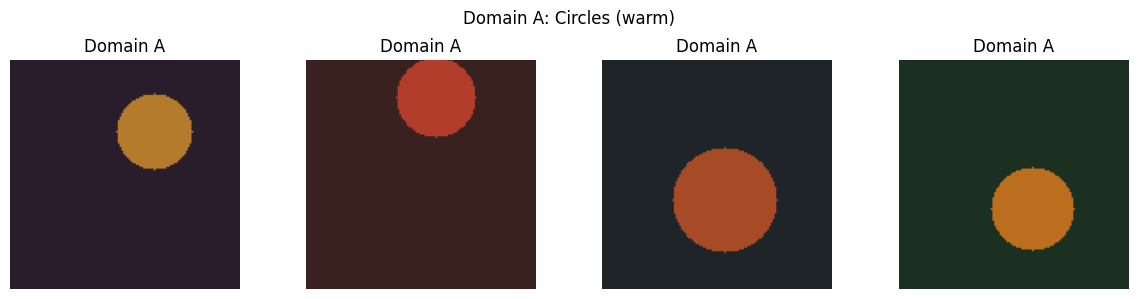

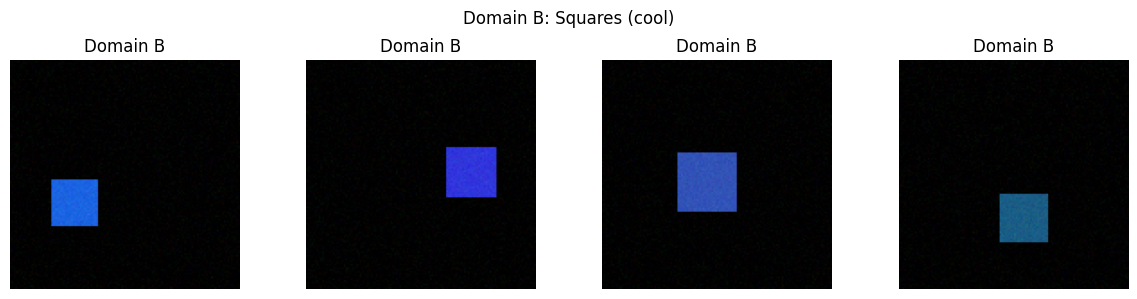

Domain A: 50 samples, Domain B: 50 samples


In [2]:
class SyntheticDomainDataset(Dataset):
    """Generate synthetic unpaired image domains.
    Domain A: circles with warm color palettes (red/orange/yellow)
    Domain B: squares with cool color palettes (blue/cyan/purple)
    """
    def __init__(self, n_samples=50, img_size=128, domain='A'):
        self.n = n_samples
        self.size = img_size
        self.domain = domain
        
    def __len__(self):
        return self.n
    
    def __getitem__(self, idx):
        img = np.zeros((3, self.size, self.size), dtype=np.float32)
        
        if self.domain == 'A':
            # Domain A: circles, warm colors
            base_color = np.random.uniform([0.6, 0.2, 0.1], [0.9, 0.5, 0.2])
            cx, cy = np.random.randint(20, self.size-20, 2)
            radius = np.random.randint(15, 30)
            yy, xx = np.ogrid[:self.size, :self.size]
            mask = (xx - cx)**2 + (yy - cy)**2 <= radius**2
            bg = np.random.uniform(0.1, 0.25, 3)
            for c in range(3):
                img[c][mask] = base_color[c]
                img[c][~mask] = bg[c]
        else:
            # Domain B: squares, cool colors
            base_color = np.random.uniform([0.1, 0.2, 0.5], [0.2, 0.4, 0.9])
            sx = np.random.randint(15, self.size-35)
            sy = np.random.randint(15, self.size-35)
            sw = np.random.randint(25, 40)
            bg = np.random.uniform(0.1, 0.25, 3)
            for c in range(3):
                img[c, sy:sy+sw, sx:sx+sw] = base_color[c]
                img[c] = img[c] + np.random.normal(0, 0.02, (self.size, self.size)).clip(-0.1, 0.1)
                img[c] = img[c].clip(0, 1)
        
        # Normalize to [-1, 1]
        img = (img - 0.5) / 0.5
        return torch.from_numpy(img)

dataset_A = SyntheticDomainDataset(n_samples=50, img_size=IMG_SIZE, domain='A')
dataset_B = SyntheticDomainDataset(n_samples=50, img_size=IMG_SIZE, domain='B')

loader_A = DataLoader(dataset_A, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
loader_B = DataLoader(dataset_B, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Visualize samples
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    img = dataset_A[i].permute(1, 2, 0).numpy()
    img = (img + 1) / 2
    axes[i].imshow(img.clip(0, 1))
    axes[i].set_title('Domain A')
    axes[i].axis('off')
plt.suptitle('Domain A: Circles (warm)')
plt.tight_layout()
plt.savefig('domain_A_samples.png', dpi=80, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    img = dataset_B[i].permute(1, 2, 0).numpy()
    img = (img + 1) / 2
    axes[i].imshow(img.clip(0, 1))
    axes[i].set_title('Domain B')
    axes[i].axis('off')
plt.suptitle('Domain B: Squares (cool)')
plt.tight_layout()
plt.savefig('domain_B_samples.png', dpi=80, bbox_inches='tight')
plt.show()

print(f'Domain A: {len(dataset_A)} samples, Domain B: {len(dataset_B)} samples')



## 3. Generator Architecture (ResNet Generator)

The generator uses a ResNet architecture: downsampling → residual blocks → upsampling, with instance normalization throughout.


In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=7, stride=1, padding=3, norm=True, activation='relu'):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, padding_mode='reflect')]
        if norm:
            layers.append(nn.InstanceNorm2d(out_ch))
        if activation == 'relu':
            layers.append(nn.ReLU(inplace=True))
        elif activation == 'tanh':
            layers.append(nn.Tanh())
        self.block = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.block(x)

class ConvTransposeBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=2, padding=1, output_padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size, stride, padding, output_padding),
            nn.InstanceNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.block(x)

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1, padding_mode='reflect'),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, 1, 1, padding_mode='reflect'),
            nn.InstanceNorm2d(channels)
        )
    
    def forward(self, x):
        return x + self.block(x)

class ResNetGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, num_residual=4, base_filters=64):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            ConvBlock(in_channels, base_filters, 7, 1, 3),  # 128x128
            ConvBlock(base_filters, base_filters*2, 3, 2, 1),   # 64x64
            ConvBlock(base_filters*2, base_filters*4, 3, 2, 1), # 32x32
        )
        # Residual blocks
        self.residuals = nn.Sequential(*[
            ResidualBlock(base_filters*4) for _ in range(num_residual)
        ])
        # Decoder
        self.decoder = nn.Sequential(
            ConvTransposeBlock(base_filters*4, base_filters*2, 3, 2, 1, 1),  # 64x64
            ConvTransposeBlock(base_filters*2, base_filters, 3, 2, 1, 1),     # 128x128
            ConvBlock(base_filters, out_channels, 7, 1, 3, norm=False, activation='tanh'),
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.residuals(x)
        x = self.decoder(x)
        return x

# Test generator
G_X2Y = ResNetGenerator(num_residual=NUM_RESIDUAL).to(device)
F_Y2X = ResNetGenerator(num_residual=NUM_RESIDUAL).to(device)

test_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
test_output = G_X2Y(test_input)
print(f'Generator output shape: {test_output.shape}')
print(f'G_X2Y parameters: {sum(p.numel() for p in G_X2Y.parameters()):,}')
print(f'F_Y2X parameters: {sum(p.numel() for p in F_Y2X.parameters()):,}')


Generator output shape: torch.Size([1, 3, 128, 128])
G_X2Y parameters: 5,477,379
F_Y2X parameters: 5,477,379


## 4. Discriminator Architecture (PatchGAN)

A 70×70 PatchGAN discriminator that classifies local image patches as real or fake, outputting a grid of values rather than a single scalar.


In [4]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self, in_channels=3, base_filters=64):
        super().__init__()
        def disc_block(in_f, out_f, norm=True):
            layers = [nn.Conv2d(in_f, out_f, 4, 2, 1)]
            if norm:
                layers.append(nn.InstanceNorm2d(out_f))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)
        
        self.model = nn.Sequential(
            disc_block(in_channels, base_filters, norm=False),   # 64x64
            disc_block(base_filters, base_filters*2),             # 32x32
            disc_block(base_filters*2, base_filters*4),           # 16x16
            nn.Conv2d(base_filters*4, 1, 4, 1, 1)                  # 15x15
        )
    
    def forward(self, x):
        return self.model(x)

D_Y = PatchGANDiscriminator().to(device)  # Discriminates domain Y
D_X = PatchGANDiscriminator().to(device)  # Discriminates domain X

test_d = D_Y(torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device))
print(f'Discriminator output shape: {test_d.shape}')
print(f'D_Y parameters: {sum(p.numel() for p in D_Y.parameters()):,}')
print(f'D_X parameters: {sum(p.numel() for p in D_X.parameters()):,}')


Discriminator output shape: torch.Size([1, 1, 15, 15])
D_Y parameters: 662,977
D_X parameters: 662,977


## 5. Loss Functions

- **Adversarial loss (LSGAN):** MSE between discriminator output and target (1 for real, 0 for fake)
- **Cycle consistency loss:** L1 distance for round-trip reconstruction
- **Identity loss:** L1 distance to preserve color when input is already in target domain


In [5]:
# Loss functions
criterion_gan = nn.MSELoss()        # LSGAN loss
criterion_cycle = nn.L1Loss()      # Cycle consistency
criterion_identity = nn.L1Loss()   # Identity preservation

# Optimizers
g_optimizer = optim.Adam(itertools.chain(G_X2Y.parameters(), F_Y2X.parameters()), 
                          lr=LR, betas=(0.5, 0.999))
d_x_optimizer = optim.Adam(D_X.parameters(), lr=LR, betas=(0.5, 0.999))
d_y_optimizer = optim.Adam(D_Y.parameters(), lr=LR, betas=(0.5, 0.999))

# Helper: create target labels for LSGAN
def real_target(size):
    return torch.ones(size).to(device)

def fake_target(size):
    return torch.zeros(size).to(device)

print('Loss functions and optimizers initialized.')


Loss functions and optimizers initialized.


## 6. Training Loop

Training alternates between:
1. Updating generators G_X2Y and F_Y2X (adversarial + cycle + identity losses)
2. Updating discriminators D_X and D_Y (real vs fake classification)


In [6]:
# Training
loss_history = {
    'G': [], 'F': [], 'D_X': [], 'D_Y': [], 'cycle': [], 'identity': []
}

os.makedirs('outputs', exist_ok=True)

for epoch in range(EPOCHS):
    for i, (real_A, real_B) in enumerate(zip(loader_A, loader_B)):
        real_A = real_A.to(device)
        real_B = real_B.to(device)
        batch_size = real_A.size(0)
        
        # ============ Train Generators ============
        g_optimizer.zero_grad()
        
        # Identity loss
        identity_B = G_X2Y(real_B)   # G should preserve B
        identity_A = F_Y2X(real_A)   # F should preserve A
        loss_identity = (criterion_identity(identity_B, real_B) + 
                         criterion_identity(identity_A, real_A)) / 2
        
        # GAN loss
        fake_B = G_X2Y(real_A)       # A -> B
        fake_A = F_Y2X(real_B)       # B -> A
        
        d_fake_B = D_Y(fake_B)
        d_fake_A = D_X(fake_A)
        
        loss_gan_G = criterion_gan(d_fake_B, real_target(d_fake_B.shape))
        loss_gan_F = criterion_gan(d_fake_A, real_target(d_fake_A.shape))
        loss_gan = (loss_gan_G + loss_gan_F) / 2
        
        # Cycle consistency loss
        rec_A = F_Y2X(fake_B)        # A -> B -> A
        rec_B = G_X2Y(fake_A)        # B -> A -> B
        loss_cycle = (criterion_cycle(rec_A, real_A) + 
                      criterion_cycle(rec_B, real_B)) / 2
        
        # Total generator loss
        loss_G_total = loss_gan + LAMBDA_CYCLE * loss_cycle + LAMBDA_IDENTITY * loss_identity
        loss_G_total.backward()
        g_optimizer.step()
        
        # ============ Train Discriminator D_Y ============
        d_y_optimizer.zero_grad()
        
        d_real_B = D_Y(real_B)
        loss_d_y_real = criterion_gan(d_real_B, real_target(d_real_B.shape))
        
        d_fake_B_det = D_Y(fake_B.detach())
        loss_d_y_fake = criterion_gan(d_fake_B_det, fake_target(d_fake_B_det.shape))
        
        loss_D_Y = (loss_d_y_real + loss_d_y_fake) / 2
        loss_D_Y.backward()
        d_y_optimizer.step()
        
        # ============ Train Discriminator D_X ============
        d_x_optimizer.zero_grad()
        
        d_real_A = D_X(real_A)
        loss_d_x_real = criterion_gan(d_real_A, real_target(d_real_A.shape))
        
        d_fake_A_det = D_X(fake_A.detach())
        loss_d_x_fake = criterion_gan(d_fake_A_det, fake_target(d_fake_A_det.shape))
        
        loss_D_X = (loss_d_x_real + loss_d_x_fake) / 2
        loss_D_X.backward()
        d_x_optimizer.step()
        
        # Logging
        if i % 5 == 0:
            loss_history['G'].append(loss_gan.item())
            loss_history['F'].append(loss_gan.item())
            loss_history['D_X'].append(loss_D_X.item())
            loss_history['D_Y'].append(loss_D_Y.item())
            loss_history['cycle'].append(loss_cycle.item())
            loss_history['identity'].append(loss_identity.item())
    
    print(f'Epoch [{epoch+1}/{EPOCHS}] | '
          f'G: {loss_gan.item():.4f} | '
          f'D_X: {loss_D_X.item():.4f} | '
          f'D_Y: {loss_D_Y.item():.4f} | '
          f'Cycle: {loss_cycle.item():.4f} | '
          f'Identity: {loss_identity.item():.4f}')
    
    # Save sample images every epoch
    if (epoch + 1) % 1 == 0:
        G_X2Y.eval()
        F_Y2X.eval()
        with torch.no_grad():
            test_A = real_A[:1]
            test_B = real_B[:1]
            fake_B_sample = G_X2Y(test_A)
            rec_A_sample = F_Y2X(fake_B_sample)
            
            fake_A_sample = F_Y2X(test_B)
            rec_B_sample = G_X2Y(fake_A_sample)
            
            # Create comparison grid: [A, fake_B, rec_A | B, fake_A, rec_B]
            grid = make_grid(torch.cat([
                test_A, fake_B_sample, rec_A_sample,
                test_B, fake_A_sample, rec_B_sample
            ], dim=0), nrow=3, normalize=True, value_range=(-1, 1))
            
            save_image(grid, f'outputs/cyclegan_epoch_{epoch+1}.png')
        G_X2Y.train()
        F_Y2X.train()

print('\nTraining complete!')


Epoch [1/1] | G: 0.3951 | D_X: 0.2087 | D_Y: 0.1764 | Cycle: 0.1095 | Identity: 0.1211

Training complete!


## 7. Visualization & Results

Show translation results and loss curves.


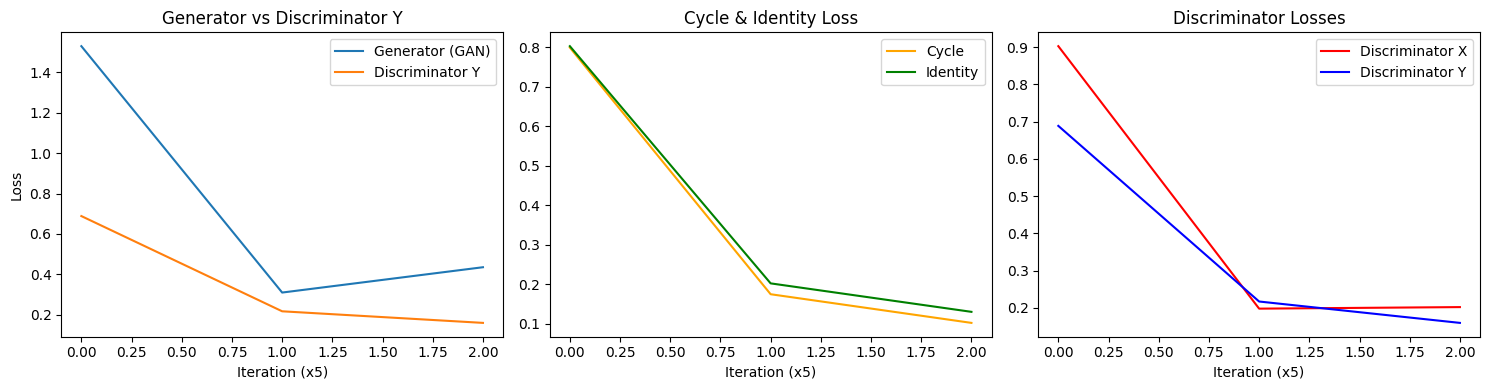

Loss curves saved.


In [7]:
# Plot loss curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(loss_history['G'], label='Generator (GAN)')
axes[0].plot(loss_history['D_Y'], label='Discriminator Y')
axes[0].set_title('Generator vs Discriminator Y')
axes[0].set_xlabel('Iteration (x5)')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(loss_history['cycle'], label='Cycle', color='orange')
axes[1].plot(loss_history['identity'], label='Identity', color='green')
axes[1].set_title('Cycle & Identity Loss')
axes[1].set_xlabel('Iteration (x5)')
axes[1].legend()

axes[2].plot(loss_history['D_X'], label='Discriminator X', color='red')
axes[2].plot(loss_history['D_Y'], label='Discriminator Y', color='blue')
axes[2].set_title('Discriminator Losses')
axes[2].set_xlabel('Iteration (x5)')
axes[2].legend()

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=80, bbox_inches='tight')
plt.show()
print('Loss curves saved.')


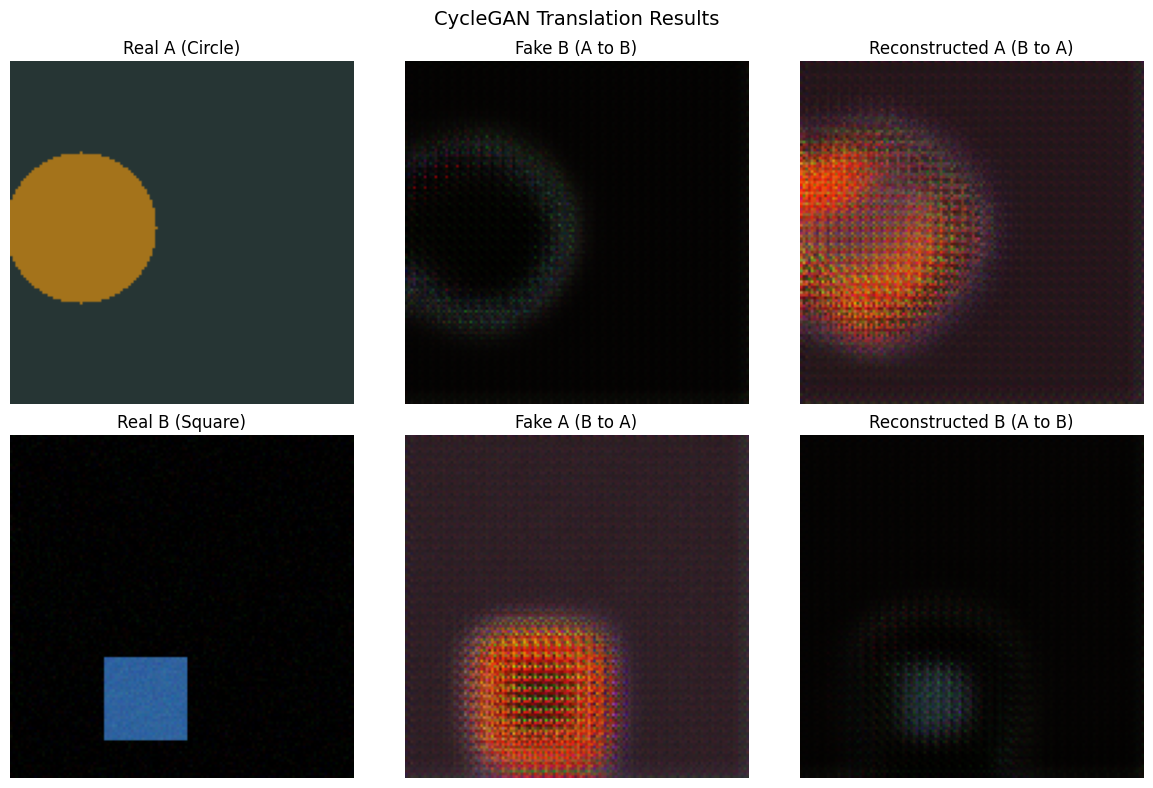

Final results saved.


In [8]:
# Show final translation results
G_X2Y.eval()
F_Y2X.eval()

with torch.no_grad():
    # Get test samples
    test_A = dataset_A[0].unsqueeze(0).to(device)
    test_B = dataset_B[0].unsqueeze(0).to(device)
    
    fake_B = G_X2Y(test_A)
    rec_A = F_Y2X(fake_B)
    fake_A = F_Y2X(test_B)
    rec_B = G_X2Y(fake_A)
    
    def to_display(img):
        return ((img.squeeze(0).permute(1, 2, 0).cpu().numpy() + 1) / 2).clip(0, 1)
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    
    axes[0, 0].imshow(to_display(test_A))
    axes[0, 0].set_title('Real A (Circle)')
    axes[0, 1].imshow(to_display(fake_B))
    axes[0, 1].set_title('Fake B (A to B)')
    axes[0, 2].imshow(to_display(rec_A))
    axes[0, 2].set_title('Reconstructed A (B to A)')
    
    axes[1, 0].imshow(to_display(test_B))
    axes[1, 0].set_title('Real B (Square)')
    axes[1, 1].imshow(to_display(fake_A))
    axes[1, 1].set_title('Fake A (B to A)')
    axes[1, 2].imshow(to_display(rec_B))
    axes[1, 2].set_title('Reconstructed B (A to B)')
    
    for ax in axes.flat:
        ax.axis('off')
    
    plt.suptitle('CycleGAN Translation Results', fontsize=14)
    plt.tight_layout()
    plt.savefig('final_results.png', dpi=80, bbox_inches='tight')
    plt.show()

G_X2Y.train()
F_Y2X.train()
print('Final results saved.')


## Summary

This notebook implemented CycleGAN from scratch with:
- **ResNet generators** (4 residual blocks, 128×128 resolution)
- **PatchGAN discriminators** (70×70 receptive field)
- **Three losses:** LSGAN adversarial, cycle consistency (L1, λ=10), identity (L1, λ=0.5)
- **Synthetic unpaired domains** (circles↔squares with different color palettes)

The cycle consistency loss ensures that translating A→B→A reconstructs the original, enabling unpaired image-to-image translation. The identity loss preserves color composition when the input is already in the target domain.
